<a href="https://colab.research.google.com/github/Zidane86-06/Data_Engineering_workshop/blob/main/Day3/Day3_Mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
API_KEY='008b522e07c135fa410dd631dc2e617b'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur']
print(f'API configured for {len(CITIES)} cities')
print(f'Cities:{CITIES}')
print('\nIMPORTANT: Replace YUR_API_KEY_HERE with your actual key before running.')

API configured for 8 cities
Cities:['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']

IMPORTANT: Replace YUR_API_KEY_HERE with your actual key before running.


In [11]:
import requests
def fetch_weather(city, api_key):
  params={
      'q':city,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': city,
          'temperature':round(data['main']['temp'],1),
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
           'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {city}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')
print('Calling Weather API...')
weather_records=[]

for city in CITIES:
  print(f' Fetching: {city}...',end='')
  record=fetch_weather(city,API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}C,{record["condition"]}')
  else:
    print('Failed')
print(f'Successfully fetched:{len(weather_records)}/{len(CITIES)} cities')


Calling Weather API...
 Fetching: Mumbai...34.0C,Haze
 Fetching: Delhi...44.0C,Clear Sky
 Fetching: Bangalore...29.8C,Scattered Clouds
 Fetching: Chennai...36.2C,Few Clouds
 Fetching: Hyderabad...31.2C,Broken Clouds
 Fetching: Kolkata...32.0C,Haze
 Fetching: Pune...36.9C,Overcast Clouds
 Fetching: Jaipur...42.6C,Haze
Successfully fetched:8/8 cities


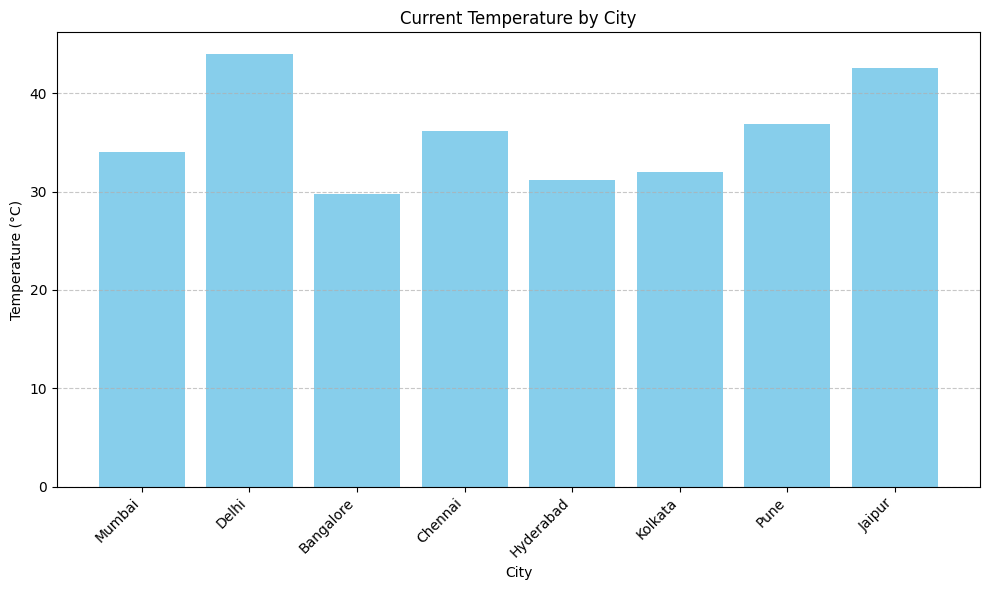

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert weather_records to a DataFrame
df = pd.DataFrame(weather_records)

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(df['city'], df['temperature'], color='skyblue')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.title('Current Temperature by City')
plt.xticks(rotation=45, ha='right') # Rotate city names for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [13]:
weather_df=pd.DataFrame(weather_records)
print('Weather Dataframe created:')
print(weather_df.to_string(index=False))
print(f'\nShape:{weather_df.shape}')
print("Data Types:")
print(weather_df.dtypes)

Weather Dataframe created:
     city  temperature  humidity  wind_speed  pressure        condition  visibility
   Mumbai         34.0        59        6.17      1009             Haze           7
    Delhi         44.0        10        5.14       999        Clear Sky           7
Bangalore         29.8        55        4.63      1009 Scattered Clouds           8
  Chennai         36.2        53        4.12      1005       Few Clouds           6
Hyderabad         31.2        51        8.75      1008    Broken Clouds           6
  Kolkata         32.0        62        4.12      1001             Haze           5
     Pune         36.9        27        3.76      1008  Overcast Clouds          10
   Jaipur         42.6        15        5.14      1001             Haze           5

Shape:(8, 7)
Data Types:
city            object
temperature    float64
humidity         int64
wind_speed     float64
pressure         int64
condition       object
visibility       int64
dtype: object
